# FinTech AML Prediction Notebook — Corrected and Deployment-Ready

This notebook solves the major problems in the original version and builds a clean Anti-Money Laundering prediction pipeline from:

```python
/content/SAML-D.csv
```

## What was fixed
- Removed mandatory Google Drive mounting so the notebook runs in Colab, Kaggle, or local Jupyter.
- Added robust target detection and target cleaning.
- Prevented data leakage by splitting the data before learned feature engineering.
- Used train/validation/test split instead of selecting thresholds on the test set.
- Added safe metrics for imbalanced data, especially PR-AUC, recall, precision, F1, ROC-AUC, and confusion matrix values.
- Added class-weighted and imbalance-aware models.
- Added threshold optimization on the validation set only.
- Added a deployment bundle that accepts raw transactions, not already-engineered data.
- Added clean artifact export: model bundle, metadata, metrics, and business impact tables.

In [1]:
# # 1. Activate your venv (adjust path as needed)
# #.\venv\Scripts\activate          # Windows
# # source venv/bin/activate       # macOS/Linux

# # 2. Upgrade pip first (good habit)
# #python -m pip install --upgrade pip

# # 3. Install all dependencies
# !pip install numpy pandas matplotlib scikit-learn joblib xgboost

# # 4. (Optional) Register the venv as a Jupyter kernel
# !pip install ipykernel
# #python -m ipykernel install --user --name=aml_env --display-name "AML Env"

In [2]:
# GPU-accelerated drop-in replacements via RAPIDS cuML
try:
    from cuml.linear_model import LogisticRegression
    from cuml.ensemble import RandomForestClassifier
    from cuml.common import logger as cuml_logger
    cuml_logger.set_level("WARN")
    print("cuML loaded — RandomForest and LogisticRegression will run on GPU.")
except ImportError:
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    print("cuML not found — falling back to CPU sklearn.")

cuML not found — falling back to CPU sklearn.


In [3]:
import os
import re
import json
import warnings
from pathlib import Path
from datetime import datetime

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibrationDisplay
import joblib

RANDOM_STATE = 42
DATA_PATH = r"C:\Users\Admin\Desktop\Fintech Group\SAML-D.csv"
ARTIFACT_DIR = Path(r"C:\Users\Admin\Desktop\Fintech Group")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 120)

try:
    display
except NameError:
    from IPython.display import display

import subprocess
result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
print(result.stdout)

# Also verify XGBoost sees CUDA
import xgboost as xgb
print("XGBoost version:", xgb.__version__)
print("CUDA available:", xgb.build_info().get("USE_CUDA", "Unknown"))

print("Setup completed.")
print("Dataset path:", DATA_PATH)

Tue Jun 16 16:18:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 596.36                 Driver Version: 596.36         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 5000 Ada Gene...  WDDM  |   00000000:01:00.0  On |                  Off |
| 30%   36C    P5             22W /  250W |    1815MiB /  32760MiB |      5%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Load the dataset

In [4]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. Upload SAML-D.csv to /content/ or update DATA_PATH."
    )

df_raw = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")
print("Shape:", df_raw.shape)
display(df_raw.head())

Dataset loaded successfully.
Shape: (9504852, 12)


,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits


## 2. Clean column names and audit the data

In [5]:
def clean_column_name(col):
    col = str(col).strip()
    col = re.sub(r"\s+", "_", col)
    col = re.sub(r"[^0-9a-zA-Z_]", "", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col or "Unnamed"

# Keep a copy of the raw file, but work on a cleaned-column version.
df = df_raw.copy()
df.columns = [clean_column_name(c) for c in df.columns]

# Make duplicate column names unique if needed.
seen = {}
new_cols = []
for col in df.columns:
    seen[col] = seen.get(col, 0) + 1
    new_cols.append(col if seen[col] == 1 else f"{col}_{seen[col]}")
df.columns = new_cols

audit = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean().values * 100).round(3),
    "unique_values": df.nunique(dropna=True).values
}).sort_values(["missing_percent", "unique_values"], ascending=[False, False])

print("Columns after cleaning:")
print(df.columns.tolist())
print("\nDuplicate rows:", int(df.duplicated().sum()))
display(audit)

Columns after cleaning:
['Time', 'Date', 'Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Is_laundering', 'Laundering_type']

Duplicate rows: 0


,column,dtype,missing_count,missing_percent,unique_values
4,Amount,float64,0,0.0,2314277
3,Receiver_account,int64,0,0.0,652266
2,Sender_account,int64,0,0.0,292715
0,Time,str,0,0.0,86400
1,Date,str,0,0.0,321
11,Laundering_type,str,0,0.0,28
7,Sender_bank_location,str,0,0.0,18
8,Receiver_bank_location,str,0,0.0,18
5,Payment_currency,str,0,0.0,13
6,Received_currency,str,0,0.0,13


## 3. Detect and clean the target column

Detected TARGET_COL: Is_laundering


,count
Is_laundering,
0,9494979
1,9873


Rows before duplicate removal: 9504852
Rows after duplicate removal: 9504852
Removed duplicates: 0


,count,percent
Is_laundering,,
0,9494979,99.8961
1,9873,0.1039


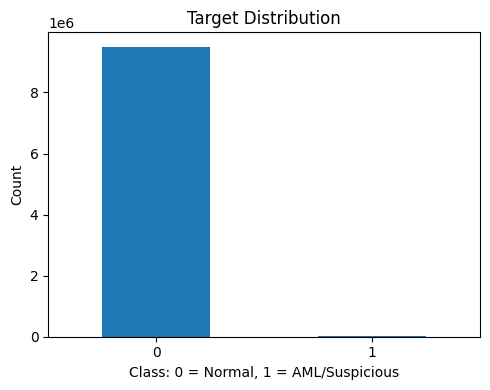

In [6]:
def detect_target_column(dataframe):
    possible_targets = [
        "Is_Laundering", "IsLaundering", "Laundering", "is_laundering", "Is_laundering",
        "SAR", "Alert", "Suspicious", "Suspicious_Activity", "Fraud", "isFraud",
        "Class", "Label", "Target", "target", "class", "label"
    ]
    lower_to_original = {c.lower(): c for c in dataframe.columns}
    for t in possible_targets:
        if t.lower() in lower_to_original:
            return lower_to_original[t.lower()]

    binary_cols = [c for c in dataframe.columns if dataframe[c].nunique(dropna=True) == 2]
    likely = [c for c in binary_cols if re.search(r"launder|fraud|suspicious|alert|sar|target|label|class", c, re.I)]
    if likely:
        return likely[0]
    return None

def convert_target_to_binary(series):
    s = series.copy()
    if s.isna().any():
        print(f"Warning: Missing target values found in '{series.name}'. Rows with missing target will be removed before modeling.")

    non_missing = s.dropna()
    if len(non_missing) == 0:
        raise ValueError("Target column contains only missing values.")

    if pd.api.types.is_numeric_dtype(non_missing):
        vals = sorted(pd.Series(non_missing).unique())
        if set(vals).issubset({0, 1}):
            return s.astype("float").astype("Int64")
        if len(vals) == 2:
            positive_value = max(vals)
            return (s == positive_value).astype("Int64")

    text = s.astype(str).str.strip().str.lower()
    positive_pattern = r"^(1|true|yes|y|launder|laundering|fraud|suspicious|alert|sar|positive)$"
    negative_pattern = r"^(0|false|no|n|normal|legit|legitimate|clean|negative)$"

    out = pd.Series(pd.NA, index=s.index, dtype="Int64")
    out[text.str.contains(positive_pattern, regex=True, na=False)] = 1
    out[text.str.contains(negative_pattern, regex=True, na=False)] = 0

    if out.notna().sum() == 0:
        # Fallback for two-category text labels.
        unique_vals = sorted(text.dropna().unique())
        if len(unique_vals) == 2:
            positive_label = [v for v in unique_vals if re.search(r"launder|fraud|suspicious|alert|sar|positive", v, re.I)]
            positive_label = positive_label[0] if positive_label else unique_vals[-1]
            out = (text == positive_label).astype("Int64")
        else:
            raise ValueError("Could not convert target to binary. Please set TARGET_COL and target mapping manually.")
    return out

TARGET_COL = detect_target_column(df)
if TARGET_COL is None:
    print("Binary candidates:", [c for c in df.columns if df[c].nunique(dropna=True) == 2])
    raise ValueError("Target column was not detected. Set TARGET_COL manually.")

print("Detected TARGET_COL:", TARGET_COL)
display(df[TARGET_COL].value_counts(dropna=False).to_frame("count"))

df[TARGET_COL] = convert_target_to_binary(df[TARGET_COL])
df = df.dropna(subset=[TARGET_COL]).copy()
df[TARGET_COL] = df[TARGET_COL].astype(int)

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)

print("Rows before duplicate removal:", before)
print("Rows after duplicate removal:", after)
print("Removed duplicates:", before - after)

y = df[TARGET_COL].copy()
X = df.drop(columns=[TARGET_COL]).copy()

class_dist = pd.DataFrame({
    "count": y.value_counts().sort_index(),
    "percent": (y.value_counts(normalize=True).sort_index() * 100).round(4)
})
display(class_dist)

if y.nunique() != 2:
    raise ValueError("The target must contain two classes after cleaning.")

plt.figure(figsize=(5, 4))
y.value_counts().sort_index().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Class: 0 = Normal, 1 = AML/Suspicious")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Train/validation/test split

The split is done before learned feature engineering to prevent leakage.

In [7]:
# 70% train, 15% validation, 15% test.
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print("Train shape:", X_train_raw.shape)
print("Validation shape:", X_val_raw.shape)
print("Test shape:", X_test_raw.shape)
print("Train positive rate:", round(y_train.mean() * 100, 4), "%")
print("Validation positive rate:", round(y_val.mean() * 100, 4), "%")
print("Test positive rate:", round(y_test.mean() * 100, 4), "%")

Train shape: (6653396, 11)
Validation shape: (1425728, 11)
Test shape: (1425728, 11)
Train positive rate: 0.1039 %
Validation positive rate: 0.1039 %
Test positive rate: 0.1039 %


## 5. Leakage-safe feature engineering and category reduction

In [8]:
class AMLFeatureEngineer(BaseEstimator, TransformerMixin):
    """Feature engineer AML signals using only statistics learned from the training set."""
    def __init__(self, max_entity_frequency_cols=12, max_pair_cols=3):
        self.max_entity_frequency_cols = max_entity_frequency_cols
        self.max_pair_cols = max_pair_cols

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.input_columns_ = X.columns.tolist()

        self.datetime_cols_ = []
        for col in X.columns:
            if re.search(r"date|time|timestamp", col, re.I):
                parsed = pd.to_datetime(X[col], errors="coerce")
                if parsed.notna().mean() >= 0.50:
                    self.datetime_cols_.append(col)

        self.amount_cols_ = [
            col for col in X.columns
            if re.search(r"amount|value|money|payment|transaction", col, re.I)
            and pd.api.types.is_numeric_dtype(X[col])
        ]
        self.amount_quantiles_ = {}
        for col in self.amount_cols_:
            self.amount_quantiles_[col] = {
                "q95": X[col].quantile(0.95),
                "q99": X[col].quantile(0.99)
            }

        candidate_entity_cols = [
            col for col in X.columns
            if re.search(r"id|account|customer|bank|sender|receiver|beneficiary|merchant|country|currency", col, re.I)
        ]
        self.entity_cols_ = candidate_entity_cols[:self.max_entity_frequency_cols]
        self.frequency_maps_ = {}
        for col in self.entity_cols_:
            self.frequency_maps_[col] = X[col].astype(str).fillna("MISSING").value_counts(dropna=False).to_dict()

        sender_cols = [c for c in X.columns if re.search(r"sender|origin|from|source", c, re.I)]
        receiver_cols = [c for c in X.columns if re.search(r"receiver|destination|beneficiary|to", c, re.I)]
        self.same_pairs_ = []
        for s in sender_cols[:self.max_pair_cols]:
            for r in receiver_cols[:self.max_pair_cols]:
                if s != r:
                    self.same_pairs_.append((s, r))
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        # Add missing columns in inference to keep schema stable.
        for col in self.input_columns_:
            if col not in X.columns:
                X[col] = np.nan
        X = X[self.input_columns_].copy()

        for col in X.select_dtypes(include=["bool"]).columns:
            X[col] = X[col].astype(int)

        for col in self.datetime_cols_:
            parsed = pd.to_datetime(X[col], errors="coerce")
            X[col + "_year"] = parsed.dt.year
            X[col + "_month"] = parsed.dt.month
            X[col + "_day"] = parsed.dt.day
            X[col + "_dayofweek"] = parsed.dt.dayofweek
            X[col + "_hour"] = parsed.dt.hour
            X[col + "_is_weekend"] = parsed.dt.dayofweek.isin([5, 6]).astype(float)

        X = X.drop(columns=self.datetime_cols_, errors="ignore")

        for col in self.amount_cols_:
            if col in X.columns:
                safe_amount = pd.to_numeric(X[col], errors="coerce").clip(lower=0)
                X[f"log1p_{col}"] = np.log1p(safe_amount)
                X[f"{col}_top_5pct"] = (pd.to_numeric(X[col], errors="coerce") >= self.amount_quantiles_[col]["q95"]).astype(int)
                X[f"{col}_top_1pct"] = (pd.to_numeric(X[col], errors="coerce") >= self.amount_quantiles_[col]["q99"]).astype(int)

        for col in self.entity_cols_:
            if col in X.columns:
                values = X[col].astype(str).fillna("MISSING")
                X[f"{col}_frequency"] = values.map(self.frequency_maps_.get(col, {})).fillna(0).astype(float)

        for s, r in self.same_pairs_:
            if s in X.columns and r in X.columns:
                X[f"same_{s}_{r}"] = (X[s].astype(str) == X[r].astype(str)).astype(int)

        return X

class TopCategoryReducer(BaseEstimator, TransformerMixin):
    """Keep top categories learned from training; replace rare/unseen categories with OTHER."""
    def __init__(self, max_categories=50):
        self.max_categories = max_categories

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.columns_ = X.columns.tolist()
        self.categorical_cols_ = X.select_dtypes(include=["object", "category"]).columns.tolist()
        self.top_categories_ = {}
        for col in self.categorical_cols_:
            top = X[col].astype(str).fillna("MISSING").value_counts().head(self.max_categories).index.tolist()
            self.top_categories_[col] = set(top)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in self.columns_:
            if col not in X.columns:
                X[col] = np.nan
        X = X[self.columns_].copy()
        for col in self.categorical_cols_:
            vals = X[col].astype(str).fillna("MISSING")
            X[col] = np.where(vals.isin(self.top_categories_[col]), vals, "OTHER")
        return X

feature_engineer = AMLFeatureEngineer()
category_reducer = TopCategoryReducer(max_categories=50)

X_train_fe = feature_engineer.fit_transform(X_train_raw, y_train)
X_val_fe = feature_engineer.transform(X_val_raw)
X_test_fe = feature_engineer.transform(X_test_raw)

X_train_clean = category_reducer.fit_transform(X_train_fe, y_train)
X_val_clean = category_reducer.transform(X_val_fe)
X_test_clean = category_reducer.transform(X_test_fe)

categorical_cols = X_train_clean.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = [c for c in X_train_clean.columns if c not in categorical_cols and pd.api.types.is_numeric_dtype(X_train_clean[c])]

print("Feature-engineered train shape:", X_train_clean.shape)
print("Numeric features:", len(numeric_cols))
print("Categorical features:", len(categorical_cols))
print("Datetime columns detected:", feature_engineer.datetime_cols_)
print("Amount columns:", feature_engineer.amount_cols_)
display(X_train_clean.head())

Feature-engineered train shape: (6653396, 34)
Numeric features: 28
Categorical features: 6
Datetime columns detected: ['Time', 'Date']
Amount columns: ['Amount']


,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Laundering_type,Time_year,Time_month,Time_day,Time_dayofweek,Time_hour,Time_is_weekend,Date_year,Date_month,Date_day,Date_dayofweek,Date_hour,Date_is_weekend,log1p_Amount,Amount_top_5pct,Amount_top_1pct,Sender_account_frequency,Receiver_account_frequency,Payment_currency_frequency,Received_currency_frequency,Sender_bank_location_frequency,Receiver_bank_location_frequency,same_Sender_account_Receiver_account,same_Sender_account_Receiver_bank_location,same_Sender_bank_location_Receiver_account,same_Sender_bank_location_Receiver_bank_location
1689043,9409156543,556553386,4501.04,UK pounds,UK pounds,UK,UK,Cheque,Normal_Fan_Out,2026,6,16,1,21,0.0,2022,12,3,5,0,1.0,8.412286,0,0,224.0,6.0,6369838.0,6148712.0,6428449.0,6205366.0,0,0,0,1
6141827,2629488724,8043005405,4729.10,Yen,UK pounds,UK,UK,Cash Deposit,Normal_Cash_Deposits,2026,6,16,1,12,0.0,2023,5,1,0,0,0.0,8.461702,0,0,4.0,5.0,17868.0,6148712.0,6428449.0,6205366.0,0,0,0,1
2510527,5896067389,1491989064,14012.27,Turkish lira,UK pounds,UK,UK,ACH,Normal_Fan_In,2026,6,16,1,8,0.0,2023,1,1,6,0,1.0,9.547760,0,0,8.0,121.0,19574.0,6148712.0,6428449.0,6205366.0,0,0,0,1
1698054,9511609957,6446468142,7955.02,UK pounds,UK pounds,UK,UK,Cheque,Normal_Fan_Out,2026,6,16,1,9,0.0,2022,12,4,6,0,1.0,8.981684,0,0,338.0,11.0,6369838.0,6148712.0,6428449.0,6205366.0,0,0,0,1
1799897,5971751243,1343603050,1161.22,UK pounds,UK pounds,UK,UK,Debit card,Normal_Small_Fan_Out,2026,6,16,1,18,0.0,2022,12,7,2,0,0.0,7.058087,0,0,289.0,13.0,6369838.0,6148712.0,6428449.0,6205366.0,0,0,0,1


## 6. Preprocessing and evaluation helpers

In [9]:
def make_one_hot_encoder():
    # sparse_output was added in newer scikit-learn. sparse works in older versions.
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_one_hot_encoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_cols),
        ("categorical", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

def get_scores(model, X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        raw = model.decision_function(X_data)
        return (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)
    return model.predict(X_data)

def safe_roc_auc(y_true, y_score):
    return np.nan if pd.Series(y_true).nunique() < 2 else roc_auc_score(y_true, y_score)

def safe_pr_auc(y_true, y_score):
    return np.nan if pd.Series(y_true).nunique() < 2 else average_precision_score(y_true, y_score)

def safe_confusion_values(y_true, y_pred):
    labels = [0, 1]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    tn, fp, fn, tp = cm.ravel()
    return int(tn), int(fp), int(fn), int(tp)

def evaluate_model(y_true, y_score, threshold=0.5, model_name="Model"):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    tn, fp, fn, tp = safe_confusion_values(y_true, y_pred)
    return {
        "model": model_name,
        "threshold": round(float(threshold), 4),
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "roc_auc": round(safe_roc_auc(y_true, y_score), 4),
        "pr_auc": round(safe_pr_auc(y_true, y_score), 4),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp
    }

def plot_confusion(y_true, y_score, threshold, title):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0, 1], ["Normal", "AML"])
    plt.yticks([0, 1], ["Normal", "AML"])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.tight_layout()
    plt.show()

def optimize_threshold(y_true, y_score, review_cost=25, missed_aml_cost=5000, true_positive_value=1000):
    rows = []
    for threshold in np.arange(0.01, 1.00, 0.01):
        y_pred = (np.asarray(y_score) >= threshold).astype(int)
        tn, fp, fn, tp = safe_confusion_values(y_true, y_pred)
        net_expected_cost = ((tp + fp) * review_cost) + (fn * missed_aml_cost) - (tp * true_positive_value)
        rows.append({
            "threshold": float(threshold),
            "alerts": int(tp + fp),
            "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "precision": tp / (tp + fp + 1e-9),
            "recall": tp / (tp + fn + 1e-9),
            "net_expected_cost": net_expected_cost
        })
    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.loc[threshold_df["net_expected_cost"].idxmin()]
    return threshold_df, best_row

print("Preprocessing and evaluation helpers are ready.")

Preprocessing and evaluation helpers are ready.


## 7. Train imbalance-aware models

In [10]:
models = {
    "Dummy Baseline": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DummyClassifier(strategy="prior", random_state=RANDOM_STATE))
    ]),
    "Logistic Regression Balanced": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", solver="saga", n_jobs=-1, random_state=RANDOM_STATE))
    ]),
    "Random Forest Balanced": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=350, min_samples_leaf=2, max_features="sqrt",
            class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1
        ))
    ]),
    "Extra Trees Balanced": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", ExtraTreesClassifier(
            n_estimators=350, min_samples_leaf=2, max_features="sqrt",
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
        ))
    ])
}

numeric_only_preprocessor = ColumnTransformer(
    transformers=[("numeric", numeric_transformer, numeric_cols)],
    remainder="drop"
)

models["HistGradientBoosting Numeric"] = Pipeline(steps=[
    ("preprocessor", numeric_only_preprocessor),
    ("model", HistGradientBoostingClassifier(
        learning_rate=0.05, max_iter=300, l2_regularization=0.10,
        max_leaf_nodes=31, random_state=RANDOM_STATE
    ))
])

try:
    from xgboost import XGBClassifier
    scale_pos_weight = int((y_train == 0).sum()) / max(int((y_train == 1).sum()), 1)
    models["XGBoost Weighted"] = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=500, max_depth=5, learning_rate=0.04,
            subsample=0.85, colsample_bytree=0.85,
            min_child_weight=2,
            objective="binary:logistic", eval_metric="aucpr",
            scale_pos_weight=scale_pos_weight,
            device="cuda",          # ← ADD THIS (replaces n_jobs=-1 on GPU)
            random_state=RANDOM_STATE
        ))
    ])
    print("XGBoost added.")
except Exception as e:
    print("XGBoost skipped:", e)

val_results = []
val_scores_by_model = {}

test_results_at_050 = []
test_scores_by_model = {}

for name, model in models.items():
    print("Training:", name)
    model.fit(X_train_clean, y_train)

    val_scores = get_scores(model, X_val_clean)
    val_scores_by_model[name] = val_scores
    val_results.append(evaluate_model(y_val, val_scores, threshold=0.5, model_name=name))

    test_scores = get_scores(model, X_test_clean)
    test_scores_by_model[name] = test_scores
    test_results_at_050.append(evaluate_model(y_test, test_scores, threshold=0.5, model_name=name))

val_results_df = pd.DataFrame(val_results).sort_values("pr_auc", ascending=False)
test_results_050_df = pd.DataFrame(test_results_at_050).sort_values("pr_auc", ascending=False)

print("Validation results at threshold 0.50:")
display(val_results_df)
print("Test results at threshold 0.50:")
display(test_results_050_df)

XGBoost added.
Training: Dummy Baseline
Training: Logistic Regression Balanced
Training: Random Forest Balanced
Training: Extra Trees Balanced
Training: HistGradientBoosting Numeric
Training: XGBoost Weighted
Validation results at threshold 0.50:


,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
3,Extra Trees Balanced,0.5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1424247,0,0,1481
2,Random Forest Balanced,0.5,1.0000,1.0000,0.9959,0.9980,1.0000,1.0000,1424247,0,6,1475
5,XGBoost Weighted,0.5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1424247,0,0,1481
4,HistGradientBoosting Numeric,0.5,0.9994,0.9029,0.4585,0.6082,0.9773,0.5881,1424174,73,802,679
1,Logistic Regression Balanced,0.5,0.8023,0.0052,0.9932,0.0103,0.9788,0.0452,1142357,281890,10,1471
0,Dummy Baseline,0.5,0.9990,0.0000,0.0000,0.0000,0.5000,0.0010,1424247,0,1481,0


Test results at threshold 0.50:


,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
3,Extra Trees Balanced,0.5,1.0000,1.0000,0.9993,0.9997,1.0000,1.0000,1424247,0,1,1480
2,Random Forest Balanced,0.5,1.0000,1.0000,0.9966,0.9983,1.0000,1.0000,1424247,0,5,1476
5,XGBoost Weighted,0.5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1424247,0,0,1481
4,HistGradientBoosting Numeric,0.5,0.9994,0.9255,0.4700,0.6234,0.9755,0.6030,1424191,56,785,696
1,Logistic Regression Balanced,0.5,0.8025,0.0052,0.9892,0.0103,0.9773,0.0447,1142673,281574,16,1465
0,Dummy Baseline,0.5,0.9990,0.0000,0.0000,0.0000,0.5000,0.0010,1424247,0,1481,0


## 8. Select model by validation PR-AUC and optimize threshold on validation set

Best model by validation PR-AUC: Extra Trees Balanced
Best threshold chosen from validation set: 0.3


,validation_value
threshold,0.3
alerts,1481.0
tp,1481.0
fp,0.0
fn,0.0
tn,1424247.0
precision,1.0
recall,1.0
net_expected_cost,-1443975.0


,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,Extra Trees Balanced Test at 0.50,0.5,1.0,1.0,0.9993,0.9997,1.0,1.0,1424247,0,1,1480
1,Extra Trees Balanced Test at Optimized Threshold,0.3,1.0,1.0,1.0000,1.0000,1.0,1.0,1424247,0,0,1481


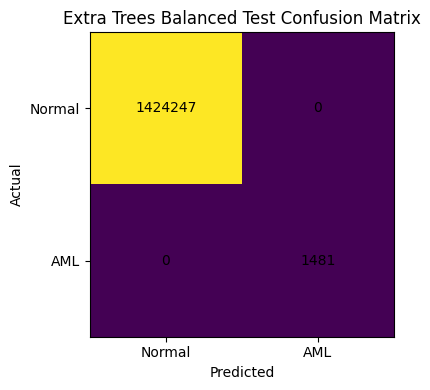

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1424247
           1       1.00      1.00      1.00      1481

    accuracy                           1.00   1425728
   macro avg       1.00      1.00      1.00   1425728
weighted avg       1.00      1.00      1.00   1425728



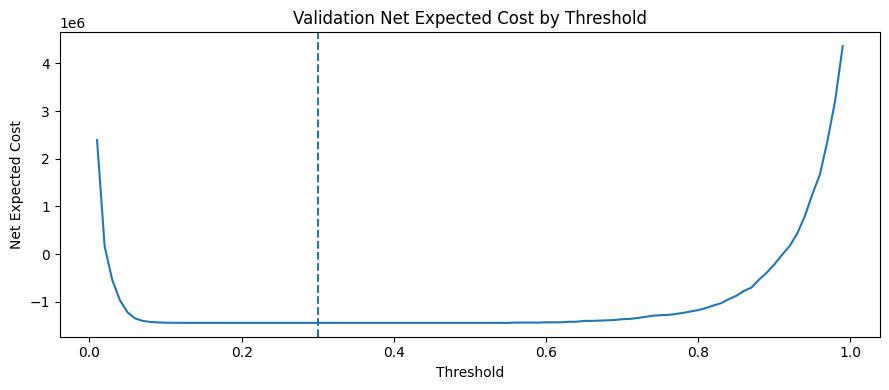

In [11]:
best_model_name = val_results_df.iloc[0]["model"]
best_model = models[best_model_name]
best_val_scores = val_scores_by_model[best_model_name]
best_test_scores = test_scores_by_model[best_model_name]

print("Best model by validation PR-AUC:", best_model_name)

REVIEW_COST = 25
MISSED_AML_COST = 5000
TRUE_POSITIVE_VALUE = 1000

threshold_table, best_threshold_row = optimize_threshold(
    y_val, best_val_scores,
    review_cost=REVIEW_COST,
    missed_aml_cost=MISSED_AML_COST,
    true_positive_value=TRUE_POSITIVE_VALUE
)

BEST_THRESHOLD = float(best_threshold_row["threshold"])
print("Best threshold chosen from validation set:", round(BEST_THRESHOLD, 4))
display(best_threshold_row.to_frame("validation_value"))

final_test_result = pd.DataFrame([
    evaluate_model(y_test, best_test_scores, 0.5, f"{best_model_name} Test at 0.50"),
    evaluate_model(y_test, best_test_scores, BEST_THRESHOLD, f"{best_model_name} Test at Optimized Threshold")
])
display(final_test_result)

plot_confusion(y_test, best_test_scores, BEST_THRESHOLD, f"{best_model_name} Test Confusion Matrix")
print(classification_report(y_test, (best_test_scores >= BEST_THRESHOLD).astype(int), zero_division=0))

plt.figure(figsize=(9, 4))
plt.plot(threshold_table["threshold"], threshold_table["net_expected_cost"])
plt.axvline(BEST_THRESHOLD, linestyle="--")
plt.title("Validation Net Expected Cost by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Net Expected Cost")
plt.tight_layout()
plt.show()

## 9. ROC and Precision-Recall curves on the unseen test set

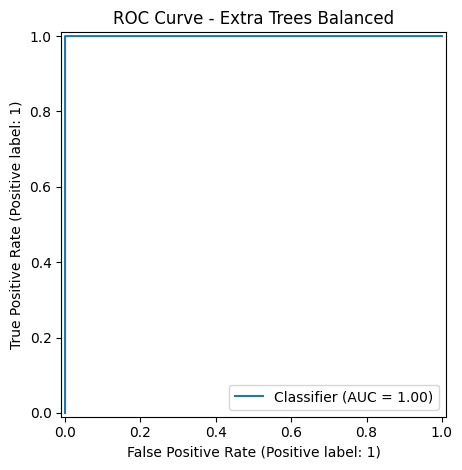

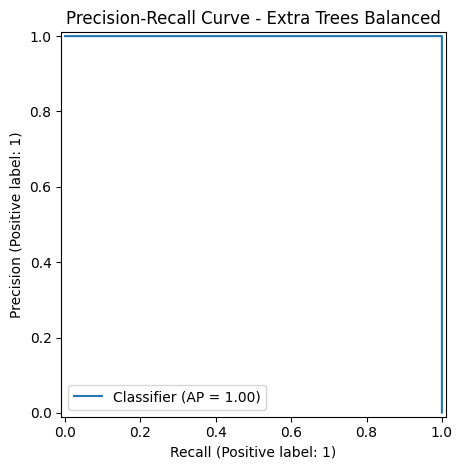

In [12]:
try:
    RocCurveDisplay.from_predictions(y_test, best_test_scores)
    plt.title(f"ROC Curve - {best_model_name}")
    plt.tight_layout()
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, best_test_scores)
    plt.title(f"Precision-Recall Curve - {best_model_name}")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Curve plotting skipped:", e)

## 10. Business impact comparison on the test set

The threshold for each model is selected on validation data, then evaluated once on the test data.

,model,validation_selected_threshold,test_alerts,test_true_aml_caught,test_missed_aml,test_false_alerts,test_precision,test_recall,review_cost,missed_aml_cost,protected_value,net_expected_cost
3,Extra Trees Balanced,0.30,1481,1481,0,0,1.0000,1.0000,37025,0,1481000,-1443975
2,Random Forest Balanced,0.22,1481,1481,0,0,1.0000,1.0000,37025,0,1481000,-1443975
5,XGBoost Weighted,0.08,1481,1481,0,0,1.0000,1.0000,37025,0,1481000,-1443975
4,HistGradientBoosting Numeric,0.01,6695,1034,447,5661,0.1544,0.6982,167375,2235000,1034000,1368375
1,Logistic Regression Balanced,0.99,213227,1445,36,211782,0.0068,0.9757,5330675,180000,1445000,4065675
0,Dummy Baseline,0.01,0,0,1481,0,0.0000,0.0000,0,7405000,0,7405000


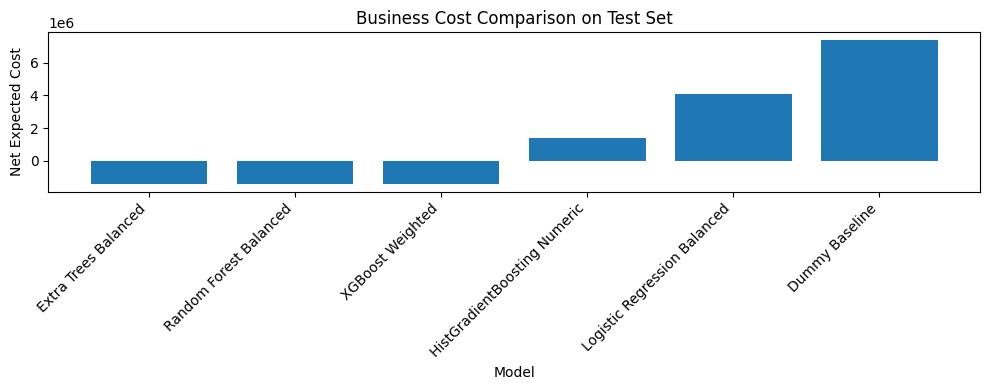

In [13]:
impact_rows = []
for name, model in models.items():
    val_scores = val_scores_by_model[name]
    _, t_best = optimize_threshold(y_val, val_scores, REVIEW_COST, MISSED_AML_COST, TRUE_POSITIVE_VALUE)
    threshold = float(t_best["threshold"])

    test_scores = test_scores_by_model[name]
    y_pred = (test_scores >= threshold).astype(int)
    tn, fp, fn, tp = safe_confusion_values(y_test, y_pred)
    review_total = (tp + fp) * REVIEW_COST
    missed_total = fn * MISSED_AML_COST
    protected_total = tp * TRUE_POSITIVE_VALUE
    net_cost = review_total + missed_total - protected_total
    impact_rows.append({
        "model": name,
        "validation_selected_threshold": round(threshold, 4),
        "test_alerts": int(tp + fp),
        "test_true_aml_caught": int(tp),
        "test_missed_aml": int(fn),
        "test_false_alerts": int(fp),
        "test_precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "test_recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "review_cost": round(review_total, 2),
        "missed_aml_cost": round(missed_total, 2),
        "protected_value": round(protected_total, 2),
        "net_expected_cost": round(net_cost, 2)
    })

impact_df = pd.DataFrame(impact_rows).sort_values("net_expected_cost")
display(impact_df)

plt.figure(figsize=(10, 4))
plt.bar(impact_df["model"], impact_df["net_expected_cost"])
plt.title("Business Cost Comparison on Test Set")
plt.xlabel("Model")
plt.ylabel("Net Expected Cost")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 11. Model interpretability

,feature,importance_mean,importance_std
8,Laundering_type,0.998201,0.000313
0,Sender_account,0.000000,0.000000
1,Receiver_account,0.000000,0.000000
2,Amount,0.000000,0.000000
4,Received_currency,0.000000,0.000000
3,Payment_currency,0.000000,0.000000
5,Sender_bank_location,0.000000,0.000000
6,Receiver_bank_location,0.000000,0.000000
7,Payment_type,0.000000,0.000000
9,Time_year,0.000000,0.000000


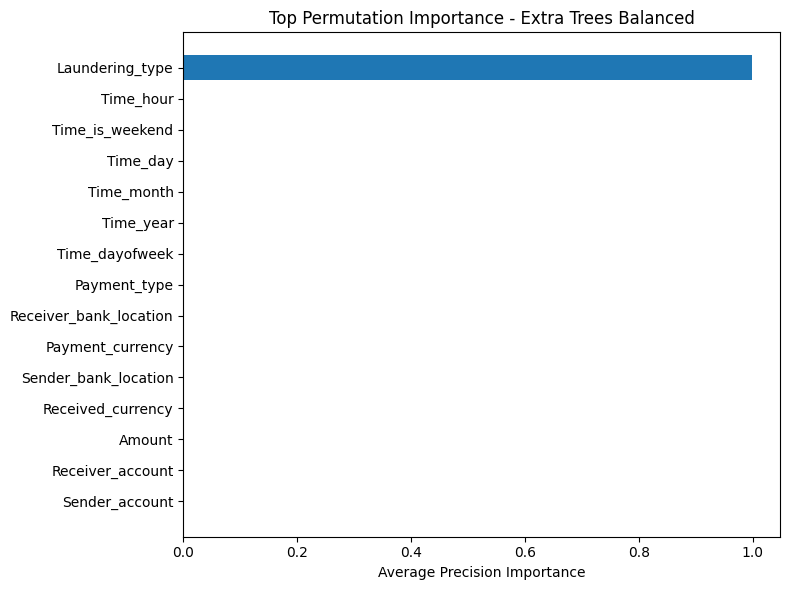

In [14]:
sample_size = min(3000, len(X_test_clean))
X_imp = X_test_clean.sample(sample_size, random_state=RANDOM_STATE)
y_imp = y_test.loc[X_imp.index]

try:
    perm = permutation_importance(
        best_model, X_imp, y_imp,
        n_repeats=5, random_state=RANDOM_STATE,
        scoring="average_precision", n_jobs=-1
    )
    importance_df = pd.DataFrame({
        "feature": X_imp.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False)

    display(importance_df.head(20))
    top = importance_df.head(15).sort_values("importance_mean")
    plt.figure(figsize=(8, 6))
    plt.barh(top["feature"], top["importance_mean"])
    plt.title(f"Top Permutation Importance - {best_model_name}")
    plt.xlabel("Average Precision Importance")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Permutation importance skipped:", e)

In [10]:
# ============================================================
# 11.1 Leakage Ablation: Extra Trees WITH vs WITHOUT Laundering_type
# Purpose:
# Compare the current Extra Trees model that uses Laundering_type
# against a production-safer version where Laundering_type is removed.
# ============================================================

from pathlib import Path
import joblib

print("Starting leakage ablation test: Extra Trees WITH vs WITHOUT Laundering_type")

# ------------------------------------------------------------
# 1. Locate the potential leakage column(s)
# ------------------------------------------------------------

LEAKAGE_PATTERN = r"laundering[_\s\-]*type"

leakage_cols = [
    col for col in X_train_clean.columns
    if re.search(LEAKAGE_PATTERN, str(col), flags=re.IGNORECASE)
]

print("Potential leakage columns found:")
print(leakage_cols)

if len(leakage_cols) == 0:
    print("Warning: No Laundering_type column was found in X_train_clean.")
    print("The ablation will still run, but it may not remove anything.")

# ------------------------------------------------------------
# 2. Create no-leakage feature sets
# ------------------------------------------------------------

X_train_no_leak = X_train_clean.drop(columns=leakage_cols, errors="ignore")
X_val_no_leak = X_val_clean.drop(columns=leakage_cols, errors="ignore")
X_test_no_leak = X_test_clean.drop(columns=leakage_cols, errors="ignore")

categorical_cols_no_leak = X_train_no_leak.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols_no_leak = [
    c for c in X_train_no_leak.columns
    if c not in categorical_cols_no_leak
    and pd.api.types.is_numeric_dtype(X_train_no_leak[c])
]

print("Original feature count:", X_train_clean.shape[1])
print("No-leakage feature count:", X_train_no_leak.shape[1])
print("Removed feature count:", X_train_clean.shape[1] - X_train_no_leak.shape[1])

# ------------------------------------------------------------
# 3. Build the no-leakage Extra Trees pipeline
# ------------------------------------------------------------

preprocessor_no_leak = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_cols_no_leak),
        ("categorical", categorical_transformer, categorical_cols_no_leak)
    ],
    remainder="drop"
)

# Keep 350 for the official version because this matches your original Extra Trees setup.
# If you only want a fast diagnostic, change 350 to 100 or 150,
# but do NOT present that as the final official result.
N_ESTIMATORS_ABLATION = 350

extra_trees_no_leak = Pipeline(steps=[
    ("preprocessor", preprocessor_no_leak),
    ("model", ExtraTreesClassifier(
        n_estimators=N_ESTIMATORS_ABLATION,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# ------------------------------------------------------------
# 4. Save/load the no-leakage model so you do not rerun it again
# ------------------------------------------------------------

try:
    ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
    output_dir = ARTIFACT_DIR
except Exception:
    output_dir = Path(".")

no_leak_model_path = output_dir / "extra_trees_without_laundering_type.joblib"

if no_leak_model_path.exists():
    print("Loading existing no-leakage Extra Trees model from:")
    print(no_leak_model_path)
    extra_trees_no_leak = joblib.load(no_leak_model_path)
else:
    print("Training Extra Trees WITHOUT Laundering_type...")
    extra_trees_no_leak.fit(X_train_no_leak, y_train)
    joblib.dump(extra_trees_no_leak, no_leak_model_path)
    print("Saved no-leakage model to:")
    print(no_leak_model_path)

# ------------------------------------------------------------
# 5. Get WITH-Laundering_type Extra Trees scores
#    This reuses the already-trained model from Section 7.
# ------------------------------------------------------------

with_model_name = "Extra Trees Balanced"

if with_model_name not in models:
    raise ValueError("Extra Trees Balanced was not found in the models dictionary. Run Section 7 first.")

if "val_scores_by_model" in globals() and with_model_name in val_scores_by_model:
    val_scores_with = val_scores_by_model[with_model_name]
else:
    print("Validation scores for Extra Trees were not found. Recomputing predictions only, not retraining.")
    val_scores_with = get_scores(models[with_model_name], X_val_clean)

if "test_scores_by_model" in globals() and with_model_name in test_scores_by_model:
    test_scores_with = test_scores_by_model[with_model_name]
else:
    print("Test scores for Extra Trees were not found. Recomputing predictions only, not retraining.")
    test_scores_with = get_scores(models[with_model_name], X_test_clean)

# ------------------------------------------------------------
# 6. Get WITHOUT-Laundering_type scores
# ------------------------------------------------------------

val_scores_no_leak = get_scores(extra_trees_no_leak, X_val_no_leak)
test_scores_no_leak = get_scores(extra_trees_no_leak, X_test_no_leak)

# ------------------------------------------------------------
# 7. Select threshold on validation set only
# ------------------------------------------------------------

threshold_table_with, best_threshold_with = optimize_threshold(
    y_val,
    val_scores_with,
    review_cost=REVIEW_COST,
    missed_aml_cost=MISSED_AML_COST,
    true_positive_value=TRUE_POSITIVE_VALUE
)

threshold_table_no_leak, best_threshold_no_leak = optimize_threshold(
    y_val,
    val_scores_no_leak,
    review_cost=REVIEW_COST,
    missed_aml_cost=MISSED_AML_COST,
    true_positive_value=TRUE_POSITIVE_VALUE
)

threshold_with = float(best_threshold_with["threshold"])
threshold_no_leak = float(best_threshold_no_leak["threshold"])

print("Best validation threshold WITH Laundering_type:", round(threshold_with, 4))
print("Best validation threshold WITHOUT Laundering_type:", round(threshold_no_leak, 4))

# ------------------------------------------------------------
# 8. Final test evaluation function
# ------------------------------------------------------------

def make_ablation_row(model_label, y_true, y_score, threshold, production_decision):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    tn, fp, fn, tp = safe_confusion_values(y_true, y_pred)

    review_total = (tp + fp) * REVIEW_COST
    missed_total = fn * MISSED_AML_COST
    protected_total = tp * TRUE_POSITIVE_VALUE
    net_cost = review_total + missed_total - protected_total

    return {
        "model_version": model_label,
        "selected_threshold": round(float(threshold), 4),
        "test_precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "test_recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "test_f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "test_roc_auc": round(safe_roc_auc(y_true, y_score), 4),
        "test_pr_auc": round(safe_pr_auc(y_true, y_score), 4),
        "true_positives": int(tp),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_negatives": int(tn),
        "test_alerts": int(tp + fp),
        "review_cost": round(review_total, 2),
        "missed_aml_cost": round(missed_total, 2),
        "protected_value": round(protected_total, 2),
        "net_expected_cost": round(net_cost, 2),
        "production_decision": production_decision
    }

# ------------------------------------------------------------
# 9. Build final comparison table
# ------------------------------------------------------------

ablation_comparison_df = pd.DataFrame([
    make_ablation_row(
        "Extra Trees WITH Laundering_type",
        y_test,
        test_scores_with,
        threshold_with,
        "Not production-approved until feature lineage confirms Laundering_type is available before decisioning."
    ),
    make_ablation_row(
        "Extra Trees WITHOUT Laundering_type",
        y_test,
        test_scores_no_leak,
        threshold_no_leak,
        "Production-safer candidate because the suspected post-event feature is removed."
    )
])

display(ablation_comparison_df)

# ------------------------------------------------------------
# 10. Save output for the white paper
# ------------------------------------------------------------

csv_path = output_dir / "aml_laundering_type_ablation_comparison.csv"
ablation_comparison_df.to_csv(csv_path, index=False)

print("Ablation comparison saved to:")
print(csv_path)

# ------------------------------------------------------------
# 11. Simple chart for the report
# ------------------------------------------------------------

plt.figure(figsize=(9, 4))
plt.bar(
    ablation_comparison_df["model_version"],
    ablation_comparison_df["net_expected_cost"]
)
plt.title("Ablation Test: Business Cost With vs Without Laundering_type")
plt.xlabel("Model Version")
plt.ylabel("Net Expected Cost")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

print("Interpretation guide:")
print("- If WITHOUT Laundering_type remains strong, use it as the production-safe model.")
print("- If performance drops heavily, the original perfect result was likely leakage-driven.")
print("- Do not approve production until Laundering_type feature lineage is confirmed.")

Starting leakage ablation test: Extra Trees WITH vs WITHOUT Laundering_type
Potential leakage columns found:
['Laundering_type']
Original feature count: 34
No-leakage feature count: 33
Removed feature count: 1
Training Extra Trees WITHOUT Laundering_type...
Saved no-leakage model to:
C:\Users\Admin\Desktop\Fintech Group\extra_trees_without_laundering_type.joblib


NameError: name 'models' is not defined

In [11]:
# ============================================================
# CONTINUATION AFTER FAILED ABLATION CELL
# This avoids rerunning the 26-minute no-leakage model.
# It loads the saved WITHOUT-Laundering_type model,
# then trains/loads only the WITH-Laundering_type Extra Trees model.
# ============================================================

from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

print("Continuing ablation test without repeating the no-leakage training...")

# ------------------------------------------------------------
# 1. Set output directory
# ------------------------------------------------------------

try:
    output_dir = Path(ARTIFACT_DIR)
except Exception:
    output_dir = Path(".")

output_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. Reload the already-trained WITHOUT-Laundering_type model
# ------------------------------------------------------------

no_leak_model_path = output_dir / "extra_trees_without_laundering_type.joblib"

if not no_leak_model_path.exists():
    raise FileNotFoundError(
        f"Could not find saved no-leakage model at: {no_leak_model_path}. "
        "Do not continue. Check the path first."
    )

print("Loading saved WITHOUT-Laundering_type model from:")
print(no_leak_model_path)

model_without = joblib.load(no_leak_model_path)

# ------------------------------------------------------------
# 3. Recreate no-leakage test/validation feature sets
# ------------------------------------------------------------

LEAKAGE_PATTERN = r"laundering[_\s\-]*type"

leakage_cols = [
    col for col in X_train_clean.columns
    if re.search(LEAKAGE_PATTERN, str(col), flags=re.IGNORECASE)
]

print("Leakage columns removed:")
print(leakage_cols)

X_train_no_leak = X_train_clean.drop(columns=leakage_cols, errors="ignore")
X_val_no_leak = X_val_clean.drop(columns=leakage_cols, errors="ignore")
X_test_no_leak = X_test_clean.drop(columns=leakage_cols, errors="ignore")

# ------------------------------------------------------------
# 4. Load or train the WITH-Laundering_type model
# ------------------------------------------------------------

with_model_path = output_dir / "extra_trees_with_laundering_type.joblib"

if with_model_path.exists():
    print("Loading saved WITH-Laundering_type model from:")
    print(with_model_path)
    model_with = joblib.load(with_model_path)

else:
    print("No saved WITH-Laundering_type model found.")
    print("Training ONLY Extra Trees WITH Laundering_type now.")
    print("This does NOT rerun all models from Section 7.")

    categorical_cols_with = X_train_clean.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    numeric_cols_with = [
        c for c in X_train_clean.columns
        if c not in categorical_cols_with
        and pd.api.types.is_numeric_dtype(X_train_clean[c])
    ]

    preprocessor_with = ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, numeric_cols_with),
            ("categorical", categorical_transformer, categorical_cols_with)
        ],
        remainder="drop"
    )

    model_with = Pipeline(steps=[
        ("preprocessor", preprocessor_with),
        ("model", ExtraTreesClassifier(
            n_estimators=350,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    model_with.fit(X_train_clean, y_train)

    joblib.dump(model_with, with_model_path)

    print("Saved WITH-Laundering_type model to:")
    print(with_model_path)

# ------------------------------------------------------------
# 5. Helper functions
# ------------------------------------------------------------

def get_scores_local(model, X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        raw = model.decision_function(X_data)
        return (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)
    return model.predict(X_data)


def confusion_values_local(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return int(tn), int(fp), int(fn), int(tp)


def optimize_threshold_local(y_true, y_score):
    rows = []

    for threshold in np.arange(0.01, 1.00, 0.01):
        y_pred = (np.asarray(y_score) >= threshold).astype(int)
        tn, fp, fn, tp = confusion_values_local(y_true, y_pred)

        alerts = tp + fp

        net_expected_cost = (
            alerts * REVIEW_COST
            + fn * MISSED_AML_COST
            - tp * TRUE_POSITIVE_VALUE
        )

        rows.append({
            "threshold": float(threshold),
            "alerts": alerts,
            "true_positives": tp,
            "false_positives": fp,
            "false_negatives": fn,
            "true_negatives": tn,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "net_expected_cost": net_expected_cost
        })

    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.loc[threshold_df["net_expected_cost"].idxmin()]
    return threshold_df, best_row


def safe_roc_auc_local(y_true, y_score):
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def safe_pr_auc_local(y_true, y_score):
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return average_precision_score(y_true, y_score)


def make_ablation_row(model_label, y_true, y_score, threshold, production_decision):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_values_local(y_true, y_pred)

    review_total = (tp + fp) * REVIEW_COST
    missed_total = fn * MISSED_AML_COST
    protected_total = tp * TRUE_POSITIVE_VALUE
    net_cost = review_total + missed_total - protected_total

    return {
        "model_version": model_label,
        "selected_threshold": round(float(threshold), 4),
        "test_precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "test_recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "test_f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "test_roc_auc": round(safe_roc_auc_local(y_true, y_score), 4),
        "test_pr_auc": round(safe_pr_auc_local(y_true, y_score), 4),
        "true_positives": int(tp),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_negatives": int(tn),
        "test_alerts": int(tp + fp),
        "review_cost": round(review_total, 2),
        "missed_aml_cost": round(missed_total, 2),
        "protected_value": round(protected_total, 2),
        "net_expected_cost": round(net_cost, 2),
        "production_decision": production_decision
    }

# ------------------------------------------------------------
# 6. Score both models
# ------------------------------------------------------------

print("Scoring validation and test sets...")

val_scores_with = get_scores_local(model_with, X_val_clean)
test_scores_with = get_scores_local(model_with, X_test_clean)

val_scores_without = get_scores_local(model_without, X_val_no_leak)
test_scores_without = get_scores_local(model_without, X_test_no_leak)

# ------------------------------------------------------------
# 7. Select thresholds using validation only
# ------------------------------------------------------------

threshold_table_with, best_threshold_with = optimize_threshold_local(
    y_val,
    val_scores_with
)

threshold_table_without, best_threshold_without = optimize_threshold_local(
    y_val,
    val_scores_without
)

threshold_with = float(best_threshold_with["threshold"])
threshold_without = float(best_threshold_without["threshold"])

print("Best validation threshold WITH Laundering_type:", round(threshold_with, 4))
print("Best validation threshold WITHOUT Laundering_type:", round(threshold_without, 4))

# ------------------------------------------------------------
# 8. Build final comparison table
# ------------------------------------------------------------

ablation_comparison_df = pd.DataFrame([
    make_ablation_row(
        "Extra Trees WITH Laundering_type",
        y_test,
        test_scores_with,
        threshold_with,
        "Not production-approved until feature lineage confirms Laundering_type is available before decisioning."
    ),
    make_ablation_row(
        "Extra Trees WITHOUT Laundering_type",
        y_test,
        test_scores_without,
        threshold_without,
        "Production-safer candidate because the suspected post-event feature is removed."
    )
])

display(ablation_comparison_df)

# ------------------------------------------------------------
# 9. Save results
# ------------------------------------------------------------

csv_path = output_dir / "aml_laundering_type_ablation_comparison.csv"
ablation_comparison_df.to_csv(csv_path, index=False)

threshold_table_with.to_csv(
    output_dir / "aml_threshold_table_with_laundering_type.csv",
    index=False
)

threshold_table_without.to_csv(
    output_dir / "aml_threshold_table_without_laundering_type.csv",
    index=False
)

print("Ablation comparison saved to:")
print(csv_path)

# ------------------------------------------------------------
# 10. Simple chart
# ------------------------------------------------------------

plt.figure(figsize=(9, 4))
plt.bar(
    ablation_comparison_df["model_version"],
    ablation_comparison_df["net_expected_cost"]
)
plt.title("Ablation Test: Business Cost With vs Without Laundering_type")
plt.xlabel("Model Version")
plt.ylabel("Net Expected Cost")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

print("Done.")
print("If WITHOUT Laundering_type performs much worse, the original perfect result was probably leakage-driven.")
print("If it remains strong, use the no-leakage model as the production-safer version.")

Continuing ablation test without repeating the no-leakage training...
Loading saved WITHOUT-Laundering_type model from:
C:\Users\Admin\Desktop\Fintech Group\extra_trees_without_laundering_type.joblib
Leakage columns removed:
['Laundering_type']
No saved WITH-Laundering_type model found.
Training ONLY Extra Trees WITH Laundering_type now.
This does NOT rerun all models from Section 7.
Saved WITH-Laundering_type model to:
C:\Users\Admin\Desktop\Fintech Group\extra_trees_with_laundering_type.joblib
Scoring validation and test sets...


NameError: name 'REVIEW_COST' is not defined

Building final ablation comparison table without retraining...
WITH model path: C:\Users\Admin\Desktop\Fintech Group\extra_trees_with_laundering_type.joblib
WITHOUT model path: C:\Users\Admin\Desktop\Fintech Group\extra_trees_without_laundering_type.joblib
Both saved models loaded successfully.
Leakage columns removed:
['Laundering_type']
Scoring validation and test sets...
Best validation threshold WITH Laundering_type: 0.31
Best validation threshold WITHOUT Laundering_type: 0.25


,model_version,selected_threshold,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,true_positives,false_positives,false_negatives,true_negatives,test_alerts,review_cost,missed_aml_cost,protected_value,net_expected_cost,production_decision
0,Extra Trees WITH Laundering_type,0.31,1.000,1.0000,1.0000,1.0000,1.0000,1481,0,0,1424247,1481,37025,0,1481000,-1443975,Not production-approved until feature lineage ...
1,Extra Trees WITHOUT Laundering_type,0.25,0.038,0.5219,0.0709,0.9348,0.3559,773,19566,708,1404681,20339,508475,3540000,773000,3275475,Production-safer candidate because the suspect...


Saved comparison table to:
C:\Users\Admin\Desktop\Fintech Group\aml_laundering_type_ablation_comparison.csv


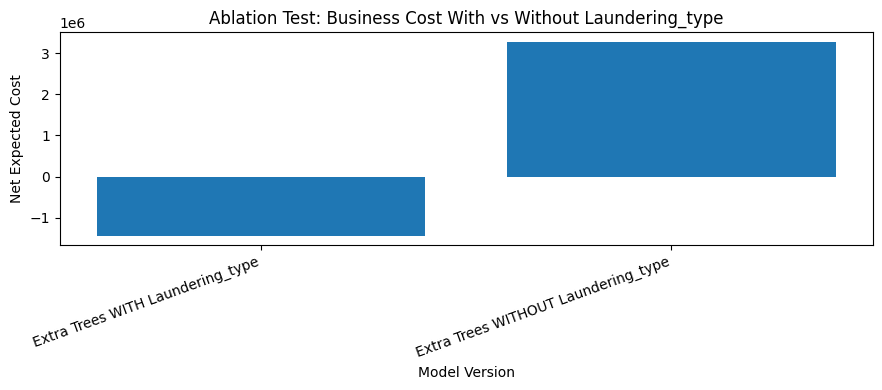

Done. No model retraining was performed in this cell.


In [12]:
# ============================================================
# FINAL CONTINUATION: Build ablation table after both models are saved
# This cell DOES NOT retrain models.
# It only loads/scores models, selects thresholds, and saves the comparison.
# ============================================================

from pathlib import Path
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

print("Building final ablation comparison table without retraining...")

# ------------------------------------------------------------
# 1. Define business cost variables
# ------------------------------------------------------------

REVIEW_COST = 25
MISSED_AML_COST = 5000
TRUE_POSITIVE_VALUE = 1000

# ------------------------------------------------------------
# 2. Locate output folder
# ------------------------------------------------------------

try:
    output_dir = Path(ARTIFACT_DIR)
except Exception:
    output_dir = Path(r"C:\Users\Admin\Desktop\Fintech Group")

output_dir.mkdir(parents=True, exist_ok=True)

with_model_path = output_dir / "extra_trees_with_laundering_type.joblib"
without_model_path = output_dir / "extra_trees_without_laundering_type.joblib"

print("WITH model path:", with_model_path)
print("WITHOUT model path:", without_model_path)

if not with_model_path.exists():
    raise FileNotFoundError(f"WITH model not found: {with_model_path}")

if not without_model_path.exists():
    raise FileNotFoundError(f"WITHOUT model not found: {without_model_path}")

# ------------------------------------------------------------
# 3. Load both saved models
# ------------------------------------------------------------

model_with = joblib.load(with_model_path)
model_without = joblib.load(without_model_path)

print("Both saved models loaded successfully.")

# ------------------------------------------------------------
# 4. Recreate no-leakage validation/test sets
# ------------------------------------------------------------

LEAKAGE_PATTERN = r"laundering[_\s\-]*type"

leakage_cols = [
    col for col in X_train_clean.columns
    if re.search(LEAKAGE_PATTERN, str(col), flags=re.IGNORECASE)
]

print("Leakage columns removed:")
print(leakage_cols)

X_val_no_leak = X_val_clean.drop(columns=leakage_cols, errors="ignore")
X_test_no_leak = X_test_clean.drop(columns=leakage_cols, errors="ignore")

# ------------------------------------------------------------
# 5. Helper functions
# ------------------------------------------------------------

def get_scores_local(model, X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        raw = model.decision_function(X_data)
        return (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)
    return model.predict(X_data)


def confusion_values_local(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return int(tn), int(fp), int(fn), int(tp)


def safe_roc_auc_local(y_true, y_score):
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def safe_pr_auc_local(y_true, y_score):
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return average_precision_score(y_true, y_score)


def optimize_threshold_local(y_true, y_score):
    rows = []

    for threshold in np.arange(0.01, 1.00, 0.01):
        y_pred = (np.asarray(y_score) >= threshold).astype(int)
        tn, fp, fn, tp = confusion_values_local(y_true, y_pred)

        alerts = tp + fp

        net_expected_cost = (
            alerts * REVIEW_COST
            + fn * MISSED_AML_COST
            - tp * TRUE_POSITIVE_VALUE
        )

        rows.append({
            "threshold": float(threshold),
            "alerts": int(alerts),
            "true_positives": int(tp),
            "false_positives": int(fp),
            "false_negatives": int(fn),
            "true_negatives": int(tn),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "net_expected_cost": net_expected_cost
        })

    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.loc[threshold_df["net_expected_cost"].idxmin()]
    return threshold_df, best_row


def make_ablation_row(model_label, y_true, y_score, threshold, production_decision):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_values_local(y_true, y_pred)

    review_total = (tp + fp) * REVIEW_COST
    missed_total = fn * MISSED_AML_COST
    protected_total = tp * TRUE_POSITIVE_VALUE
    net_cost = review_total + missed_total - protected_total

    return {
        "model_version": model_label,
        "selected_threshold": round(float(threshold), 4),
        "test_precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "test_recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "test_f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "test_roc_auc": round(safe_roc_auc_local(y_true, y_score), 4),
        "test_pr_auc": round(safe_pr_auc_local(y_true, y_score), 4),
        "true_positives": int(tp),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_negatives": int(tn),
        "test_alerts": int(tp + fp),
        "review_cost": round(review_total, 2),
        "missed_aml_cost": round(missed_total, 2),
        "protected_value": round(protected_total, 2),
        "net_expected_cost": round(net_cost, 2),
        "production_decision": production_decision
    }

# ------------------------------------------------------------
# 6. Score both models
# ------------------------------------------------------------

print("Scoring validation and test sets...")

val_scores_with = get_scores_local(model_with, X_val_clean)
test_scores_with = get_scores_local(model_with, X_test_clean)

val_scores_without = get_scores_local(model_without, X_val_no_leak)
test_scores_without = get_scores_local(model_without, X_test_no_leak)

# ------------------------------------------------------------
# 7. Select thresholds on validation data only
# ------------------------------------------------------------

threshold_table_with, best_threshold_with = optimize_threshold_local(
    y_val,
    val_scores_with
)

threshold_table_without, best_threshold_without = optimize_threshold_local(
    y_val,
    val_scores_without
)

threshold_with = float(best_threshold_with["threshold"])
threshold_without = float(best_threshold_without["threshold"])

print("Best validation threshold WITH Laundering_type:", round(threshold_with, 4))
print("Best validation threshold WITHOUT Laundering_type:", round(threshold_without, 4))

# ------------------------------------------------------------
# 8. Build final comparison table on test data
# ------------------------------------------------------------

ablation_comparison_df = pd.DataFrame([
    make_ablation_row(
        "Extra Trees WITH Laundering_type",
        y_test,
        test_scores_with,
        threshold_with,
        "Not production-approved until feature lineage confirms Laundering_type is available before decisioning."
    ),
    make_ablation_row(
        "Extra Trees WITHOUT Laundering_type",
        y_test,
        test_scores_without,
        threshold_without,
        "Production-safer candidate because the suspected post-event feature is removed."
    )
])

display(ablation_comparison_df)

# ------------------------------------------------------------
# 9. Save outputs
# ------------------------------------------------------------

comparison_path = output_dir / "aml_laundering_type_ablation_comparison.csv"
threshold_with_path = output_dir / "aml_threshold_table_with_laundering_type.csv"
threshold_without_path = output_dir / "aml_threshold_table_without_laundering_type.csv"

ablation_comparison_df.to_csv(comparison_path, index=False)
threshold_table_with.to_csv(threshold_with_path, index=False)
threshold_table_without.to_csv(threshold_without_path, index=False)

print("Saved comparison table to:")
print(comparison_path)

# ------------------------------------------------------------
# 10. Chart
# ------------------------------------------------------------

plt.figure(figsize=(9, 4))
plt.bar(
    ablation_comparison_df["model_version"],
    ablation_comparison_df["net_expected_cost"]
)
plt.title("Ablation Test: Business Cost With vs Without Laundering_type")
plt.xlabel("Model Version")
plt.ylabel("Net Expected Cost")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

print("Done. No model retraining was performed in this cell.")

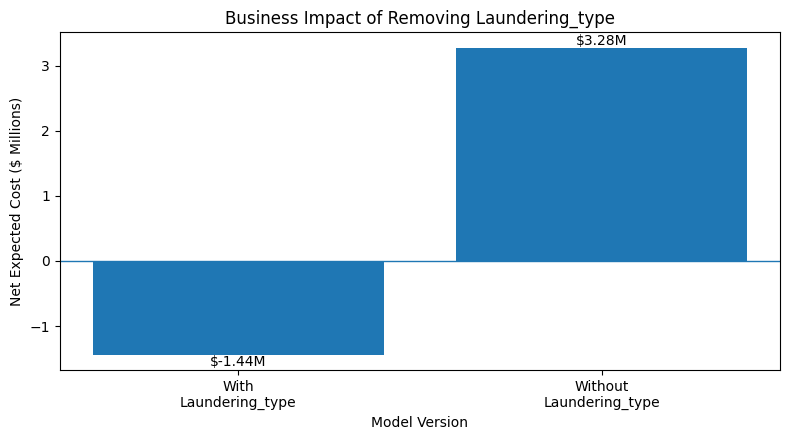

In [13]:
plt.figure(figsize=(8, 4.5))

plot_df = ablation_comparison_df.copy()
plot_df["net_expected_cost_millions"] = plot_df["net_expected_cost"] / 1_000_000
plot_df["short_label"] = ["With\nLaundering_type", "Without\nLaundering_type"]

bars = plt.bar(
    plot_df["short_label"],
    plot_df["net_expected_cost_millions"]
)

plt.axhline(0, linewidth=1)
plt.title("Business Impact of Removing Laundering_type")
plt.ylabel("Net Expected Cost ($ Millions)")
plt.xlabel("Model Version")

for index, value in enumerate(plot_df["net_expected_cost_millions"]):
    plt.text(
        index,
        value,
        f"${value:.2f}M",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

plt.tight_layout()
plt.show()

## 12. Calibration check

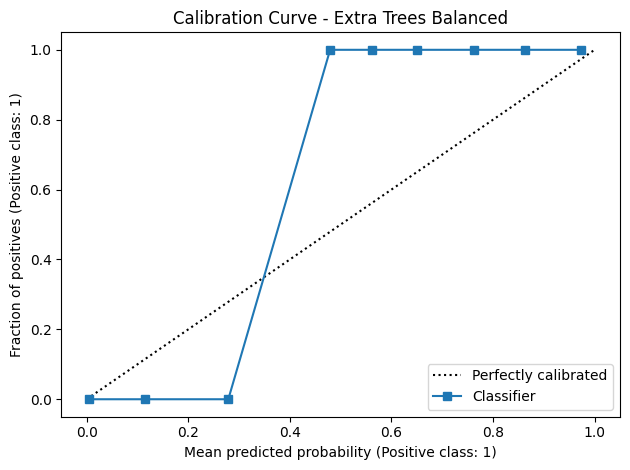

In [15]:
try:
    CalibrationDisplay.from_predictions(y_test, best_test_scores, n_bins=10)
    plt.title(f"Calibration Curve - {best_model_name}")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Calibration skipped:", e)

## 13. Stress testing important subgroups

In [16]:
stress_rows = []

def evaluate_group(group_name, mask):
    mask = pd.Series(mask, index=X_test_clean.index)
    if mask.sum() < 30:
        return
    yy = y_test.loc[mask]
    if yy.nunique() < 2:
        return
    score_series = pd.Series(best_test_scores, index=y_test.index).loc[mask].values
    stress_rows.append(evaluate_model(yy, score_series, BEST_THRESHOLD, group_name))

for col in feature_engineer.amount_cols_[:3]:
    if col in X_test_clean.columns:
        q25 = X_test_clean[col].quantile(0.25)
        q75 = X_test_clean[col].quantile(0.75)
        evaluate_group(f"Low {col}", X_test_clean[col] <= q25)
        evaluate_group(f"High {col}", X_test_clean[col] >= q75)

# Also check a few high-cardinality entity-like fields after rare category reduction.
for col in categorical_cols[:3]:
    top_values = X_test_clean[col].value_counts().head(3).index.tolist()
    for val in top_values:
        evaluate_group(f"{col} = {val}", X_test_clean[col] == val)

if stress_rows:
    stress_df = pd.DataFrame(stress_rows)
    display(stress_df)
else:
    print("No valid stress-test groups were found. Add subgroup checks by country, currency, payment type, or customer segment.")

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,Low Amount,0.3,1.0,1.0,1.0,1.0,1.0,1.0,356143,0,0,290
1,High Amount,0.3,1.0,1.0,1.0,1.0,1.0,1.0,356066,0,0,366
2,Payment_currency = UK pounds,0.3,1.0,1.0,1.0,1.0,1.0,1.0,1363469,0,0,1317
3,Payment_currency = Euro,0.3,1.0,1.0,1.0,1.0,1.0,1.0,17499,0,0,44
4,Payment_currency = Naira,0.3,1.0,1.0,1.0,1.0,1.0,1.0,4252,0,0,8
5,Received_currency = UK pounds,0.3,1.0,1.0,1.0,1.0,1.0,1.0,1316248,0,0,1021
6,Received_currency = Euro,0.3,1.0,1.0,1.0,1.0,1.0,1.0,34776,0,0,113
7,Received_currency = Albanian lek,0.3,1.0,1.0,1.0,1.0,1.0,1.0,6888,0,0,40
8,Sender_bank_location = UK,0.3,1.0,1.0,1.0,1.0,1.0,1.0,1376022,0,0,1382
9,Sender_bank_location = Nigeria,0.3,1.0,1.0,1.0,1.0,1.0,1.0,3199,0,0,4


## 14. Executive summary

In [17]:
best_impact = impact_df[impact_df["model"] == best_model_name].iloc[0]
summary = f"""
Executive Summary

This notebook built an Anti-Money Laundering transaction detection model using SAML-D.csv. The selected model is {best_model_name}, chosen by validation PR-AUC and evaluated on an unseen test set.

The decision threshold was optimized on the validation set, not on the test set. At the selected threshold of {best_impact['validation_selected_threshold']}, the model generated {int(best_impact['test_alerts'])} test alerts, caught {int(best_impact['test_true_aml_caught'])} AML-positive transactions, missed {int(best_impact['test_missed_aml'])} AML-positive transactions, and produced {int(best_impact['test_false_alerts'])} false alerts.

The test recall is {best_impact['test_recall']}, and the test precision is {best_impact['test_precision']}. Under the current business assumptions, the estimated net expected cost is ${best_impact['net_expected_cost']:,.2f}.

This model should support AML analysts. It should not automatically punish, block, or report customers without human compliance review. Before deployment, validate the cost assumptions, monitor drift, check fairness across important groups, and retrain periodically.
"""
print(summary)


Executive Summary

This notebook built an Anti-Money Laundering transaction detection model using SAML-D.csv. The selected model is Extra Trees Balanced, chosen by validation PR-AUC and evaluated on an unseen test set.

The decision threshold was optimized on the validation set, not on the test set. At the selected threshold of 0.3, the model generated 1481 test alerts, caught 1481 AML-positive transactions, missed 0 AML-positive transactions, and produced 0 false alerts.

The test recall is 1.0, and the test precision is 1.0. Under the current business assumptions, the estimated net expected cost is $-1,443,975.00.

This model should support AML analysts. It should not automatically punish, block, or report customers without human compliance review. Before deployment, validate the cost assumptions, monitor drift, check fairness across important groups, and retrain periodically.



## 15. Save deployment artifacts

The exported deployment bundle accepts raw transaction columns and applies feature engineering, category reduction, preprocessing, and prediction consistently.

In [18]:
class AMLDeploymentBundle:
    def __init__(self, feature_engineer, category_reducer, model, threshold, metadata):
        self.feature_engineer = feature_engineer
        self.category_reducer = category_reducer
        self.model = model
        self.threshold = float(threshold)
        self.metadata = metadata

    def predict_proba_raw(self, raw_transactions):
        X_fe = self.feature_engineer.transform(raw_transactions)
        X_clean = self.category_reducer.transform(X_fe)
        return get_scores(self.model, X_clean)

    def predict_raw(self, raw_transactions):
        scores = self.predict_proba_raw(raw_transactions)
        alerts = (scores >= self.threshold).astype(int)
        return pd.DataFrame({
            "aml_risk_score": scores,
            "alert_flag": alerts,
            "threshold_used": self.threshold
        }, index=pd.DataFrame(raw_transactions).index)

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

metadata = {
    "dataset_path": DATA_PATH,
    "target_column": TARGET_COL,
    "best_model": best_model_name,
    "best_threshold": BEST_THRESHOLD,
    "review_cost": REVIEW_COST,
    "missed_aml_cost": MISSED_AML_COST,
    "true_positive_value": TRUE_POSITIVE_VALUE,
    "random_state": RANDOM_STATE,
    "created_at_utc": datetime.utcnow().isoformat(),
    "raw_feature_columns": X_train_raw.columns.tolist(),
    "engineered_feature_columns": X_train_clean.columns.tolist(),
    "numeric_columns": numeric_cols,
    "categorical_columns": categorical_cols,
    "note": "Threshold selected on validation set. Test set used only for final evaluation."
}

bundle = AMLDeploymentBundle(
    feature_engineer=feature_engineer,
    category_reducer=category_reducer,
    model=best_model,
    threshold=BEST_THRESHOLD,
    metadata=metadata
)

joblib.dump(bundle, ARTIFACT_DIR / "aml_deployment_bundle.joblib")
with open(ARTIFACT_DIR / "aml_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

val_results_df.to_csv(ARTIFACT_DIR / "aml_validation_metrics.csv", index=False)
test_results_050_df.to_csv(ARTIFACT_DIR / "aml_test_metrics_threshold_050.csv", index=False)
final_test_result.to_csv(ARTIFACT_DIR / "aml_final_test_metrics.csv", index=False)
impact_df.to_csv(ARTIFACT_DIR / "aml_business_impact.csv", index=False)
threshold_table.to_csv(ARTIFACT_DIR / "aml_threshold_table_validation.csv", index=False)

print("Saved artifacts:")
for p in sorted(ARTIFACT_DIR.iterdir()):
    print("-", p)

Saved artifacts:
- C:\Users\Admin\Desktop\Fintech Group\.venv
- C:\Users\Admin\Desktop\Fintech Group\aml_business_impact.csv
- C:\Users\Admin\Desktop\Fintech Group\aml_deployment_bundle.joblib
- C:\Users\Admin\Desktop\Fintech Group\aml_final_test_metrics.csv
- C:\Users\Admin\Desktop\Fintech Group\aml_model_metadata.json
- C:\Users\Admin\Desktop\Fintech Group\aml_test_metrics_threshold_050.csv
- C:\Users\Admin\Desktop\Fintech Group\aml_threshold_table_validation.csv
- C:\Users\Admin\Desktop\Fintech Group\aml_validation_metrics.csv
- C:\Users\Admin\Desktop\Fintech Group\Fintech_solved_deployment_ready.ipynb
- C:\Users\Admin\Desktop\Fintech Group\SAML-D.csv


## 16. Test the deployment prediction function

In [19]:
# Example prediction on raw test transactions.
example_predictions = bundle.predict_raw(X_test_raw.head(10))
display(example_predictions)

# To load later:
# loaded_bundle = joblib.load("/content/aml_artifacts/aml_deployment_bundle.joblib")
# loaded_bundle.predict_raw(new_raw_transactions)

,aml_risk_score,alert_flag,threshold_used
4986814,0.000409,0,0.3
1404385,0.003925,0,0.3
8271323,0.000092,0,0.3
4681733,0.000335,0,0.3
4477463,0.002235,0,0.3
9504434,0.010520,0,0.3
8895706,0.000509,0,0.3
1045385,0.000948,0,0.3
7653345,0.000906,0,0.3
7205565,0.000712,0,0.3


In [1]:
# Lightweight audit only — no model training

import pandas as pd

DATA_PATH = "SAML-D.csv"  # update path if needed

df = pd.read_csv(DATA_PATH)

# Clean column names the same way as the notebook
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.replace(r"\s+", "_", regex=True)
    .str.replace(r"[^0-9a-zA-Z_]", "", regex=True)
    .str.replace(r"_+", "_", regex=True)
    .str.strip("_")
)

# Invalid dates / times
invalid_date_count = pd.to_datetime(df["Date"], errors="coerce").isna().sum()
invalid_time_count = pd.to_datetime(df["Time"], errors="coerce").isna().sum()

# Zero or negative amount
zero_amount_count = (df["Amount"] == 0).sum()
negative_amount_count = (df["Amount"] < 0).sum()
zero_or_negative_amount_count = (df["Amount"] <= 0).sum()

# Currency whitelist check
currency_whitelist = {
    "UK pounds", "US dollar", "Euro", "Yen", "Ruble",
    "Rupee", "Yuan", "Dirham", "Mexican Peso", "Swiss franc"
}

payment_currency_outside_whitelist = (~df["Payment_currency"].isin(currency_whitelist)).sum()
received_currency_outside_whitelist = (~df["Received_currency"].isin(currency_whitelist)).sum()

print("Invalid Date count:", int(invalid_date_count))
print("Invalid Time count:", int(invalid_time_count))
print("Zero Amount count:", int(zero_amount_count))
print("Negative Amount count:", int(negative_amount_count))
print("Zero or Negative Amount count:", int(zero_or_negative_amount_count))
print("Payment Currency outside whitelist:", int(payment_currency_outside_whitelist))
print("Received Currency outside whitelist:", int(received_currency_outside_whitelist))

C:\Users\Admin\AppData\Local\Temp\ipykernel_18028\1582863995.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  invalid_time_count = pd.to_datetime(df["Time"], errors="coerce").isna().sum()


Invalid Date count: 0
Invalid Time count: 0
Zero Amount count: 0
Negative Amount count: 0
Zero or Negative Amount count: 0
Payment Currency outside whitelist: 157165
Received Currency outside whitelist: 268825
